# BRAIN TUMOR CLASSIFICATION USING MRI IMAGES

The detection and characterization of brain tumors is a major public health challenge. MRI (Magnetic Resonance Imaging) is the primary diagnostic tool for detecting and characterizing brain tumors. The three tumor types in our dataset have distinct characteristics:

- **Glioma**: Primary brain tumor developing from glial cells; often aggressive and requires prompt treatment.
- **Meningioma**: Usually benign tumor arising from the meninges; more common in women.
- **Pituitary tumor**: Tumor of the pituitary gland, usually benign but can affect hormone levels.

## INSTALLATION OF REQUIRED PACKAGES

In [ ]:
pip install numpy pandas matplotlib seaborn opencv-python scikit-learn tensorflow kagglehub

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub

# Download latest version
path1 = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
path2 = kagglehub.dataset_download("sofienehermi/brain-tumor-balanced")

print("Path to dataset files:", path1)
print("Path to dataset files:", path2)

100%|██████████| 86.8M/86.8M [00:05<00:00, 16.0MB/s]

Extracting files...


100%|██████████| 117M/117M [00:06<00:00, 18.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/3
Path to dataset files: /root/.cache/kagglehub/datasets/sofienehermi/brain-tumor-balanced/versions/1


In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## EXPLORATORY DATA ANALYSIS

### DATASET EXPLORATION

In [ ]:
BASE_PATH = path1
dataset_info = {
    'Training': defaultdict(int),
    'Testing': defaultdict(int)
}

image_dimensions = {
    'Training': defaultdict(list),
    'Testing': defaultdict(list)
}

# Parcourir Training et Testing
for split in ['Training', 'Testing']:
    split_path = os.path.join(BASE_PATH, split)

    if not os.path.exists(split_path):
        continue

    print(f"\n{split}")
    print("-" * 70)

    # Parcourir les classes
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            # Compter les images
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            count = len(images)
            dataset_info[split][class_name] = count

            print(f"  ├─ {class_name:25s}: {count:4d} images")

            # Échantillonner quelques images pour analyser les dimensions
            sample_size = min(50, count)
            for img_name in images[:sample_size]:
                img_path = os.path.join(class_path, img_name)
                try:
                    img = Image.open(img_path)
                    image_dimensions[split][class_name].append(img.size)
                except:
                    pass

    total = sum(dataset_info[split].values())
    print(f"  └─ {'TOTAL':25s}: {total:4d} images")


Training
----------------------------------------------------------------------
  ├─ pituitary_tumor          :  827 images
  ├─ meningioma_tumor         :  822 images
  ├─ no_tumor                 :  395 images
  ├─ glioma_tumor             :  826 images
  └─ TOTAL                    : 2870 images

Testing
----------------------------------------------------------------------
  ├─ pituitary_tumor          :   74 images
  ├─ meningioma_tumor         :  115 images
  ├─ no_tumor                 :  105 images
  ├─ glioma_tumor             :  100 images
  └─ TOTAL                    :  394 images


### IMAGE DIMESNION ANALYSIS

In [ ]:
for split in ['Training', 'Testing']:
    print(f"\n {split}:")
    print("-" * 70)

    for class_name, dims in image_dimensions[split].items():
        if dims:
            widths = [d[0] for d in dims]
            heights = [d[1] for d in dims]

            unique_dims = set(dims)

            print(f"\n  {class_name}:")
            print(f"    Unique Dimensions: {len(unique_dims)}")

            if len(unique_dims) == 1:
                print(f"    Uniform Size: {dims[0][0]}x{dims[0][1]}")
            else:
                print(f"    Width    - Min: {min(widths):4d}, Max: {max(widths):4d}, Average: {np.mean(widths):.1f}")
                print(f"    Height   - Min: {min(heights):4d}, Max: {max(heights):4d}, Average: {np.mean(heights):.1f}")
                print(f"    Most Frequent Dimensions: {max(set(dims), key=dims.count)}")


 Training:
----------------------------------------------------------------------

  pituitary_tumor:
    Unique Dimensions: 4
    Width    - Min:  201, Max:  512, Average: 499.8
    Height   - Min:  210, Max:  512, Average: 499.2
    Most Frequent Dimensions: (512, 512)

  meningioma_tumor:
    Unique Dimensions: 13
    Width    - Min:  201, Max: 1275, Average: 496.6
    Height   - Min:  225, Max: 1427, Average: 505.8
    Most Frequent Dimensions: (512, 512)

  no_tumor:
    Unique Dimensions: 39
    Width    - Min:  200, Max: 1024, Average: 335.3
    Height   - Min:  210, Max: 1075, Average: 356.5
    Most Frequent Dimensions: (236, 236)

  glioma_tumor:
    Unique Dimensions: 1
    Uniform Size: 512x512

 Testing:
----------------------------------------------------------------------

  pituitary_tumor:
    Unique Dimensions: 25
    Width    - Min:  201, Max: 1358, Average: 577.0
    Height   - Min:  202, Max: 1322, Average: 569.3
    Most Frequent Dimensions: (512, 512)

  meningi

### CLASS DISTRIBUTION ANALYSIS

In [ ]:
for split in ['Training', 'Testing']:
    print(f"\n {split}:")
    print("-" * 70)

    counts = dataset_info[split]
    if not counts:
        continue

    total = sum(counts.values())

    # Create a DataFrame for analysis
    df = pd.DataFrame({
        'Class': list(counts.keys()),
        'Count': list(counts.values()),
        'Percentage': [v/total*100 for v in counts.values()]
    })

    df = df.sort_values('Count', ascending=False)
    print(df.to_string(index=False))


 Training:
----------------------------------------------------------------------
           Class  Count  Percentage
 pituitary_tumor    827   28.815331
    glioma_tumor    826   28.780488
meningioma_tumor    822   28.641115
        no_tumor    395   13.763066

 Testing:
----------------------------------------------------------------------
           Class  Count  Percentage
meningioma_tumor    115   29.187817
        no_tumor    105   26.649746
    glioma_tumor    100   25.380711
 pituitary_tumor     74   18.781726


### VISUALIZATION OF SAMPLES

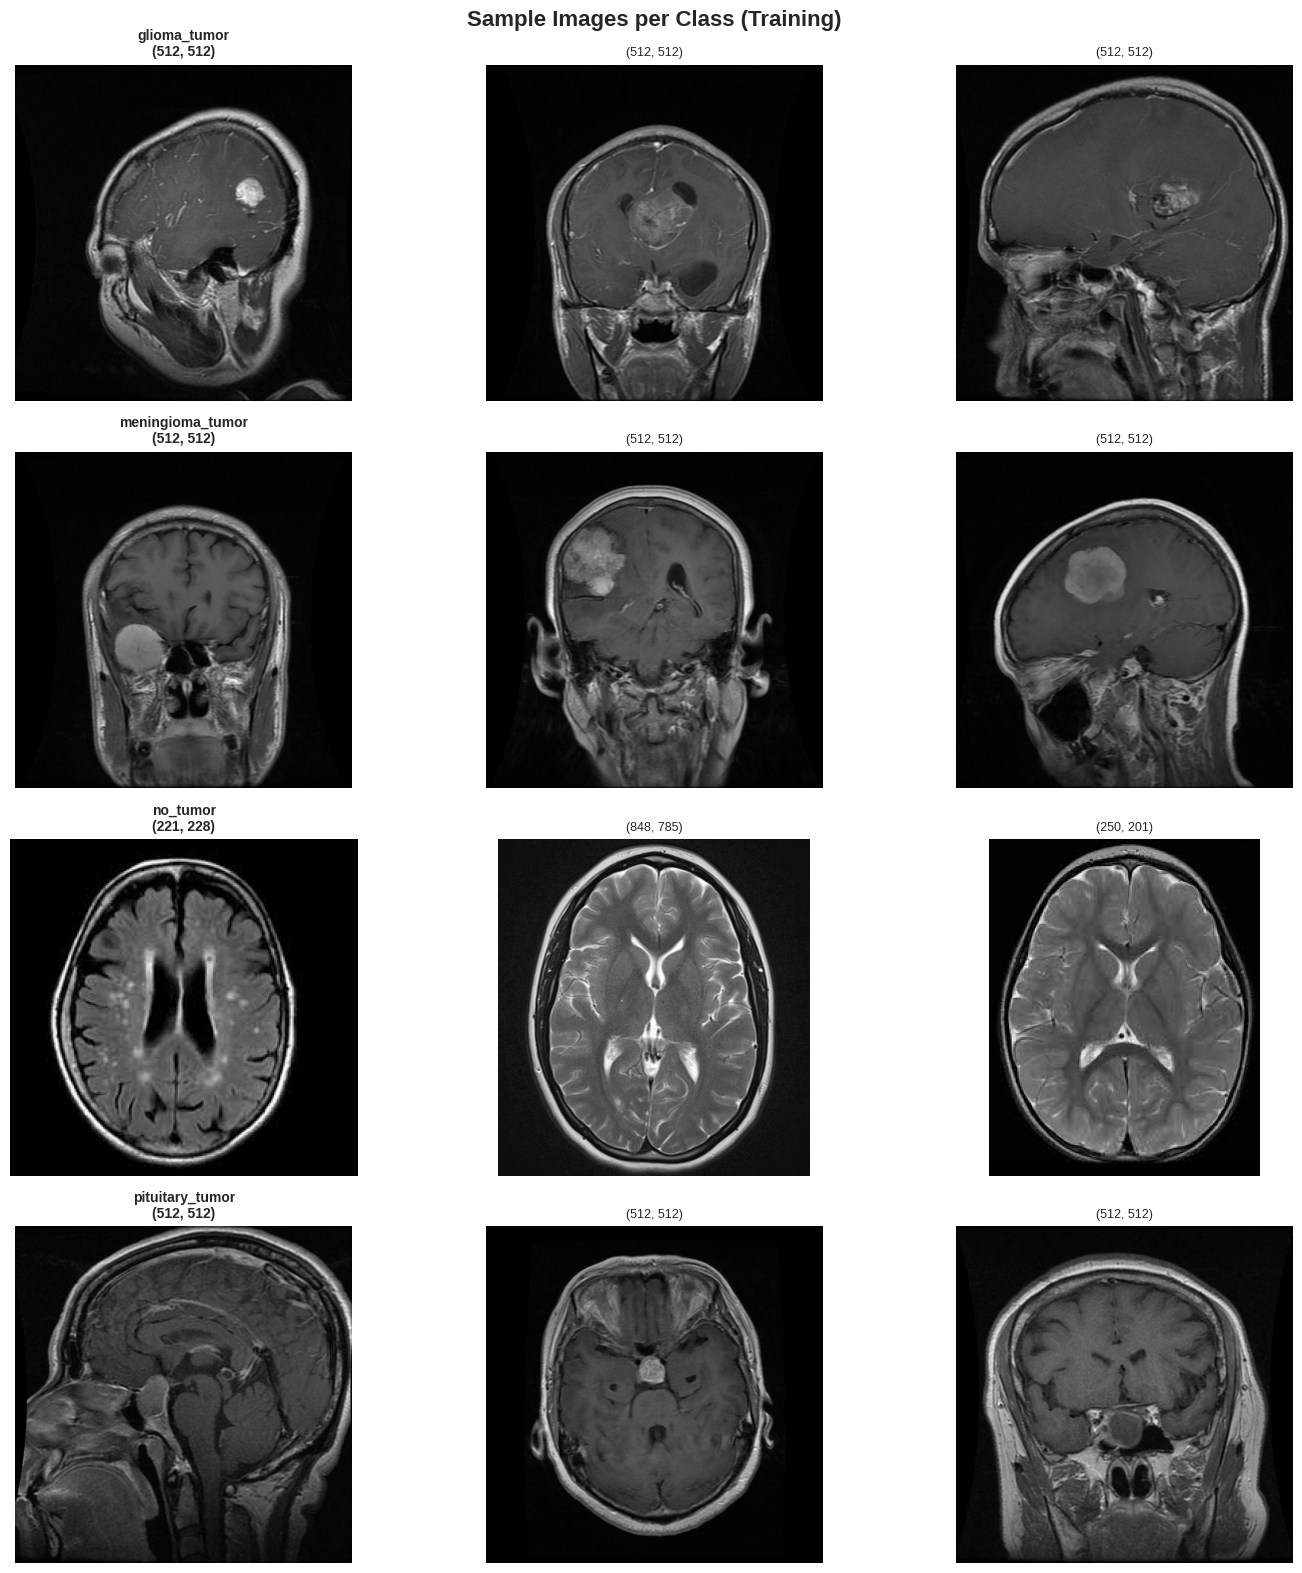

In [ ]:
split = 'Training'
split_path = os.path.join(BASE_PATH, split)
classes = sorted([d for d in os.listdir(split_path)
                 if os.path.isdir(os.path.join(split_path, d))])

samples_per_class = 3

fig, axes = plt.subplots(len(classes), samples_per_class,
                         figsize=(15, 4*len(classes)))
fig.suptitle('Sample Images per Class (Training)',
             fontsize=16, fontweight='bold')

for i, class_name in enumerate(classes):
    class_path = os.path.join(split_path, class_name)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Sélectionner des échantillons aléatoires
    samples = np.random.choice(images,
                              min(samples_per_class, len(images)),
                              replace=False)

    for j, img_name in enumerate(samples):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        ax = axes[i, j] if len(classes) > 1 else axes[j]
        ax.imshow(img, cmap='gray')
        ax.axis('off')

        if j == 0:
            ax.set_title(f"{class_name}\n{img.shape}",
                       fontsize=10, fontweight='bold')
        else:
            ax.set_title(f"{img.shape}", fontsize=9)

plt.tight_layout()
plt.show()

### CLASS DISTRIBUTION CHARTS



 Generating distribution plots...


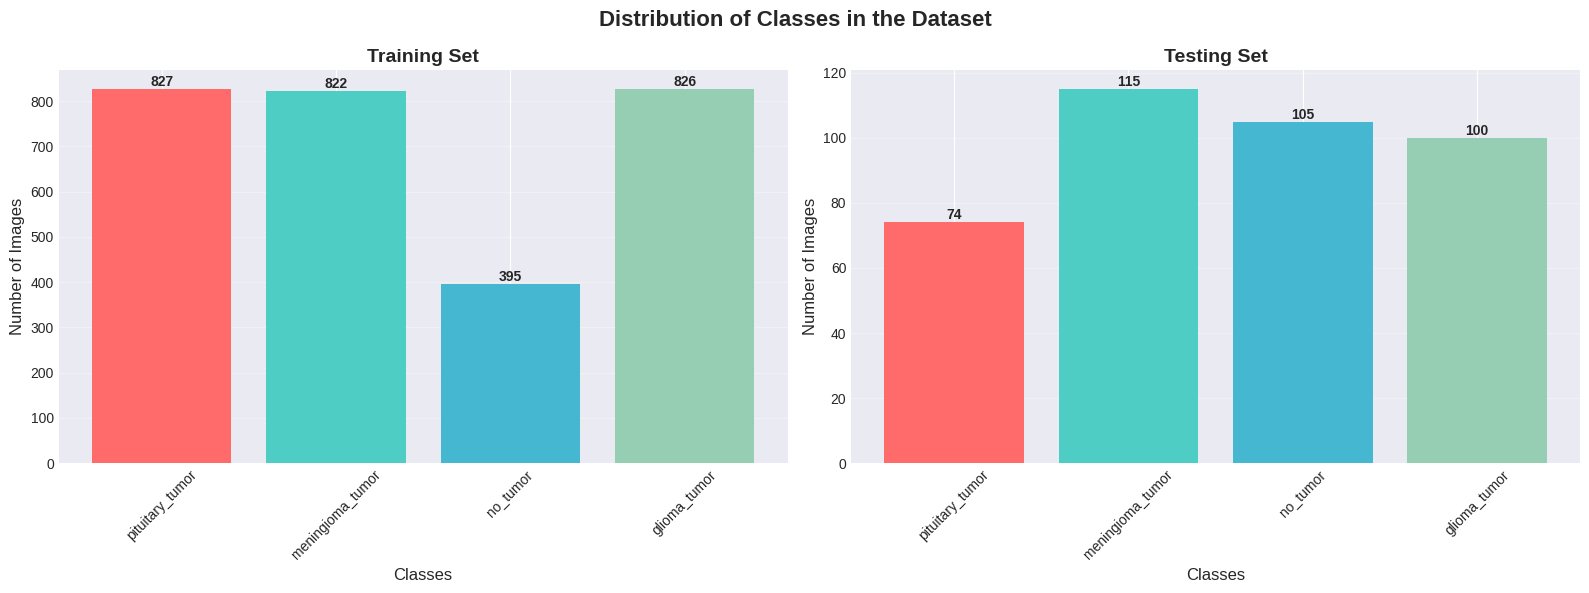

In [ ]:
print("\n Generating distribution plots...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of Classes in the Dataset',
             fontsize=16, fontweight='bold')

for idx, split in enumerate(['Training', 'Testing']):
    counts = dataset_info[split]
    if not counts:
        continue

    classes_list = list(counts.keys())
    values = list(counts.values())

    # Bar chart
    bars = axes[idx].bar(classes_list, values,
                        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    axes[idx].set_title(f'{split} Set', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Number of Images', fontsize=12)
    axes[idx].set_xlabel('Classes', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)

    # Add values on the bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height)}',
                      ha='center', va='bottom', fontweight='bold')

    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## IMAGE GENERATION USING DDPM MODEL (Denoising Diffusion Probabilistic Models)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import zipfile
from datetime import datetime
import shutil
import warnings
warnings.filterwarnings('ignore')

In [ ]:
BASE_PATH = path1
OUTPUT_BASE = '/kaggle/working/ddpm_output'

print(f"Dataset original: {BASE_PATH}")
print(f"Output: {OUTPUT_BASE}")

# Create structure
folders = [
    'original_no_tumor',
    'generated_images',
    'model',
    'samples'
]

print("\n Creating structure...")
for folder in folders:
    os.makedirs(os.path.join(OUTPUT_BASE, folder), exist_ok=True)
print(f" {len(folders)} folders created")

Dataset original: /root/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/3
Output: /kaggle/working/ddpm_output

 Creating structure...
 4 folders created


In [ ]:
no_tumor_path = os.path.join(path1, 'Training', 'no_tumor')
no_tumor_images = [f for f in os.listdir(no_tumor_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"Total no_tumor: {len(no_tumor_images)}")

temp_no_tumor = os.path.join(OUTPUT_BASE, 'original_no_tumor')

for img_name in tqdm(no_tumor_images, desc="Copie"):
    shutil.copy2(os.path.join(no_tumor_path, img_name),
                os.path.join(temp_no_tumor, img_name))

print(f" {len(no_tumor_images)} images copied")

Total no_tumor: 395


Copie: 100%|██████████| 395/395 [00:00<00:00, 7504.52it/s]

 395 images copied


In [ ]:
import subprocess
import sys

print(" Installation diffusers, torch...")
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                          "diffusers", "transformers", "accelerate", "torch", "torchvision"])
    print("Dependencies installed!")
except Exception as e:
    print(f" Error: {e}")

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from diffusers import DDPMScheduler, UNet2DModel, DDPMPipeline
from diffusers.optimization import get_cosine_schedule_with_warmup
from tqdm.auto import tqdm as tqdm_auto
from PIL import Image as PILImage

# Initialize the noise scheduler
noise_scheduler = DDPMScheduler()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n Device: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

 Installation diffusers, torch...
Dependencies installed!


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.



 Device: cuda
   GPU: Tesla T4


### PREPARATION OF THE NO_TUMOR DATASET

In [ ]:
class BrainMRIDataset(Dataset):
    def __init__(self, image_dir, image_size=128):
        self.image_dir = image_dir
        self.image_files = [f for f in os.listdir(image_dir)
                           if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = PILImage.open(img_path)
        return self.transform(image)

image_size = 128
dataset = BrainMRIDataset(temp_no_tumor, image_size=image_size)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2)

print(f"  Dataset: {len(dataset)} images")
print(f"   Batches: {len(dataloader)}")

  Dataset: 395 images
   Batches: 99


### DDPM MODEL CONFIGURATION

In [ ]:
model = UNet2DModel(
    sample_size=image_size,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 128, 256, 256, 512, 512),
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D",
        "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D",
        "UpBlock2D", "UpBlock2D", "UpBlock2D"
    ),
)
model.to(device)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

print(f"MODEL CREATED")
print(f"PARAMETERS: {sum(p.numel() for p in model.parameters()):,}")

MODEL CREATED
PARAMETERS: 113,673,219


### MODEL TRAINING

Configuration:
Epochs: 50
Learning rate: 0.0001
Batch size: 16

 TRAINING STARTING...


Epoch 1/50:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 1/50 - Loss: 0.6490


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/99 [00:00<?, ?it/s]

...

Epoch 50/50:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 50/50 - Loss: 0.0117


  0%|          | 0/50 [00:00<?, ?it/s]


 TRAINING COMPLETED.


<Figure size 640x480 with 0 Axes>

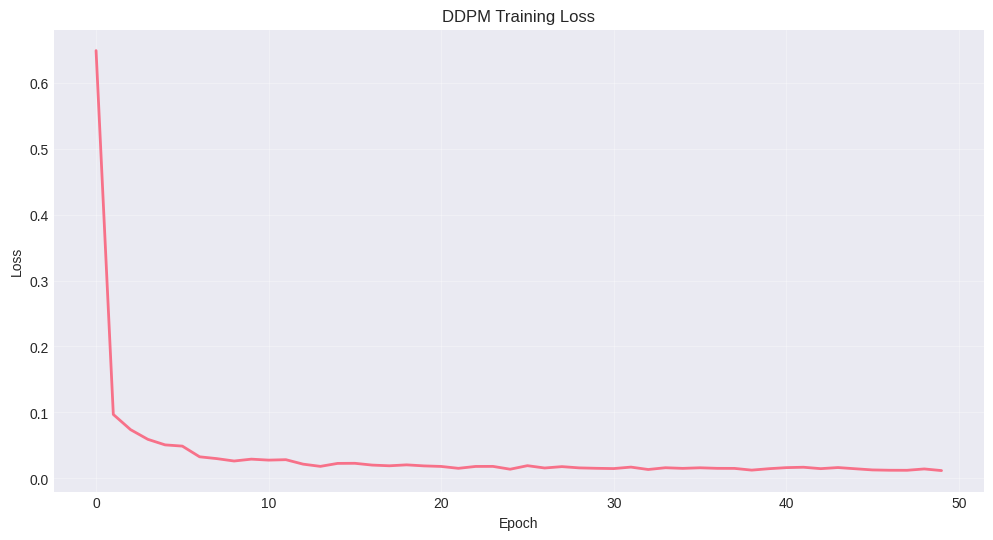

In [ ]:
num_epochs = 50
learning_rate = 1e-4

print(f"Configuration:")
print(f"Epochs: {num_epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Batch size: 16")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=(len(dataloader) * num_epochs),
)

print(f"\n TRAINING STARTING...")

model.train()
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    progress_bar = tqdm_auto(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch in progress_bar:
        clean_images = batch.to(device)
        noise = torch.randn(clean_images.shape).to(device)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                 (clean_images.shape[0],), device=device).long()

        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

    if (epoch + 1) % 10 == 0 or epoch == 0:
        model.eval()
        with torch.no_grad():
            pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
            pipeline.to(device)

            samples = pipeline(batch_size=4, num_inference_steps=50, output_type="numpy").images
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_BASE, 'samples', f'epoch_{epoch+1:03d}.png'))
        model.train()
print("\n TRAINING COMPLETED.")

# Courbe loss
plt.figure(figsize=(12, 6))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DDPM Training Loss')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_BASE, 'training_loss.png'), dpi=150, bbox_inches='tight')
plt.show() # Removed to prevent unwanted output


### FINAL IMAGE GENERATION

Images to generate: 205

 Generating images...


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  10/205


...

  0%|          | 0/50 [00:00<?, ?it/s]

  200/205


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]


 205 images generated
 Verification: 205 files

 Comparison...


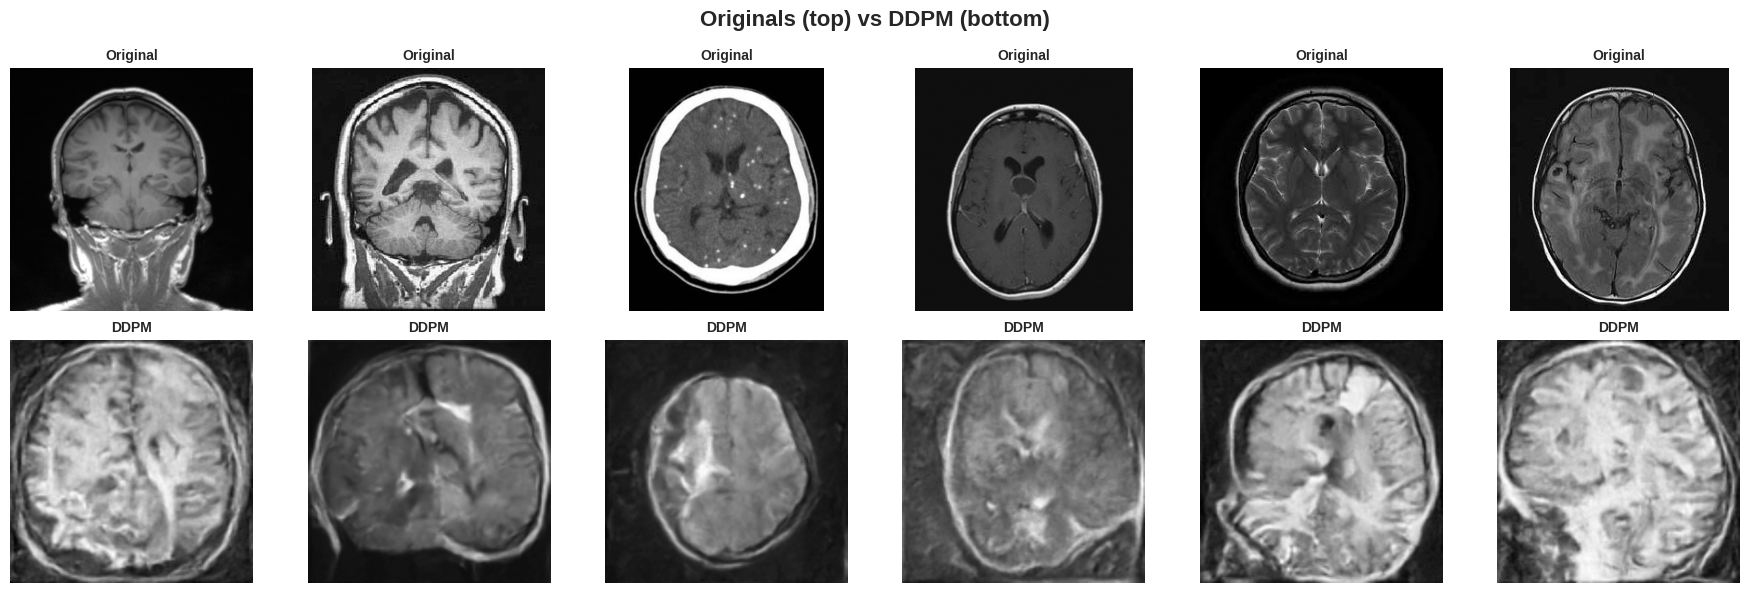

In [ ]:
target_total = 600
images_to_generate = target_total - len(no_tumor_images)

print(f"Images to generate: {images_to_generate}")

model.eval()
pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
pipeline.to(device)

generated_folder = os.path.join(OUTPUT_BASE, 'generated_images')
generated_count = 0
batch_size_gen = 4

print("\n Generating images...")

with torch.no_grad():
    while generated_count < images_to_generate:
        try:
            current_batch = min(batch_size_gen, images_to_generate - generated_count)

            output = pipeline(batch_size=current_batch, num_inference_steps=50, output_type="numpy")
            images = output.images

            for i in range(current_batch):
                try:
                    img = (images[i] * 255).astype(np.uint8)
                    img_gray = img[:, :, 0]
                    img_resized = cv2.resize(img_gray, (512, 512))

                    save_path = os.path.join(generated_folder, f'ddpm_{generated_count:04d}.jpg')
                    cv2.imwrite(save_path, img_resized)

                    generated_count += 1

                    if generated_count % 10 == 0:
                        print(f"  {generated_count}/{images_to_generate}")

                except Exception as e:
                    print(f"   Image error {generated_count}: {e}")
                    generated_count += 1

        except Exception as e:
            print(f"   Batch error: {e}")
            if generated_count >= images_to_generate * 0.8:
                break

print(f"\n {generated_count} images generated")

# Verification
saved_imgs = [f for f in os.listdir(generated_folder) if f.lower().endswith('.jpg')]
print(f" Verification: {len(saved_imgs)} files")

# Visual comparison
print("\n Comparison...")

original_samples = no_tumor_images[:6]
generated_samples = saved_imgs[:6]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Originals (top) vs DDPM (bottom)', fontsize=16, fontweight='bold')

for idx, img_name in enumerate(original_samples):
    img = cv2.imread(os.path.join(temp_no_tumor, img_name), cv2.IMREAD_GRAYSCALE)
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title('Original', fontsize=10, fontweight='bold')
    axes[0, idx].axis('off')

for idx, img_name in enumerate(generated_samples):
    img = cv2.imread(os.path.join(generated_folder, img_name), cv2.IMREAD_GRAYSCALE)
    axes[1, idx].imshow(img, cmap='gray')
    axes[1, idx].set_title('DDPM', fontsize=10, fontweight='bold')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## SUMMARY

In [ ]:
# SUMMARY
print(f"Original number of images: {len(no_tumor_images)}")
print(f"Generated images: {generated_count}")
print(f"Total number of images: {len(no_tumor_images) + generated_count}")

Original number of images: 395
Generated images: 205
Total number of images: 600


## **Data Splitting**

15% of the data from each class is reserved for validation. The original Testing folder is kept for an independent final evaluation. This choice follows best practices in machine learning and avoids information leakage.

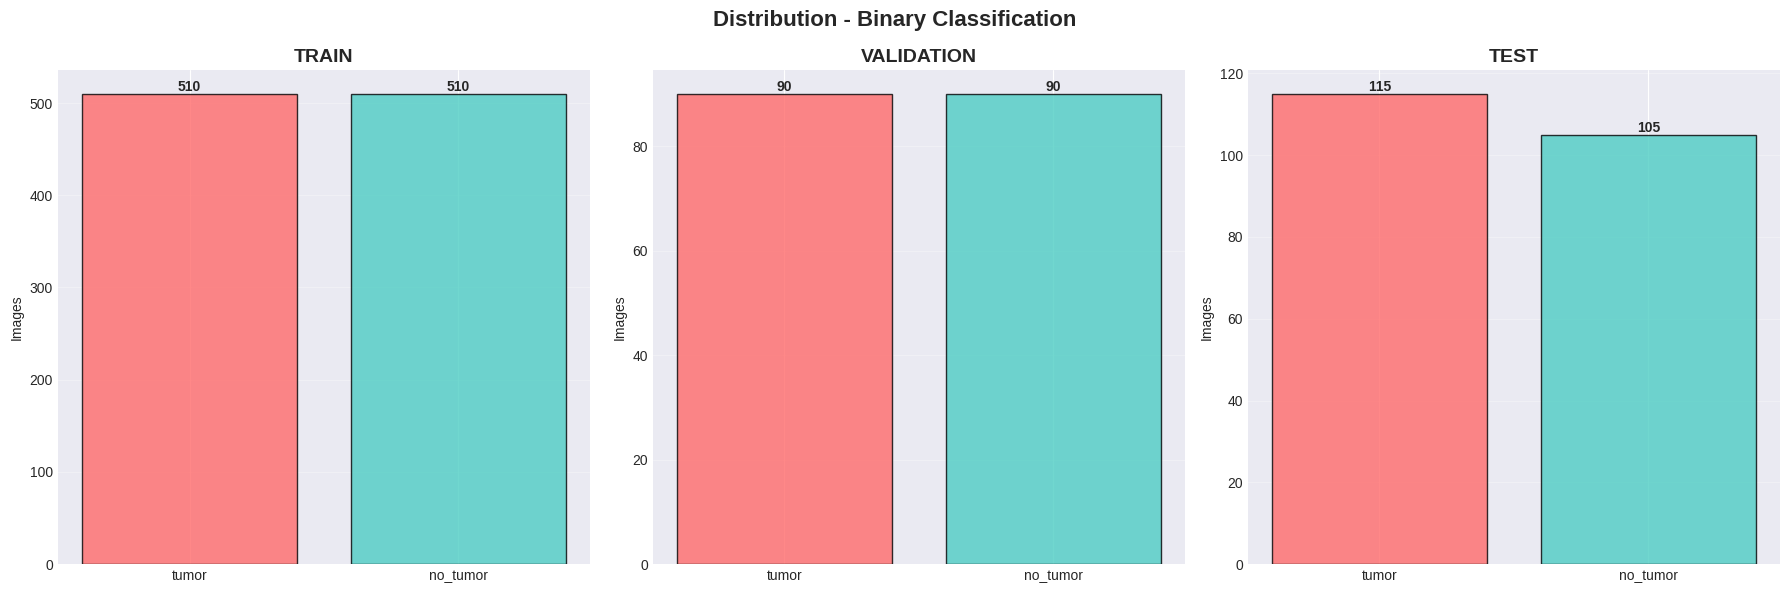

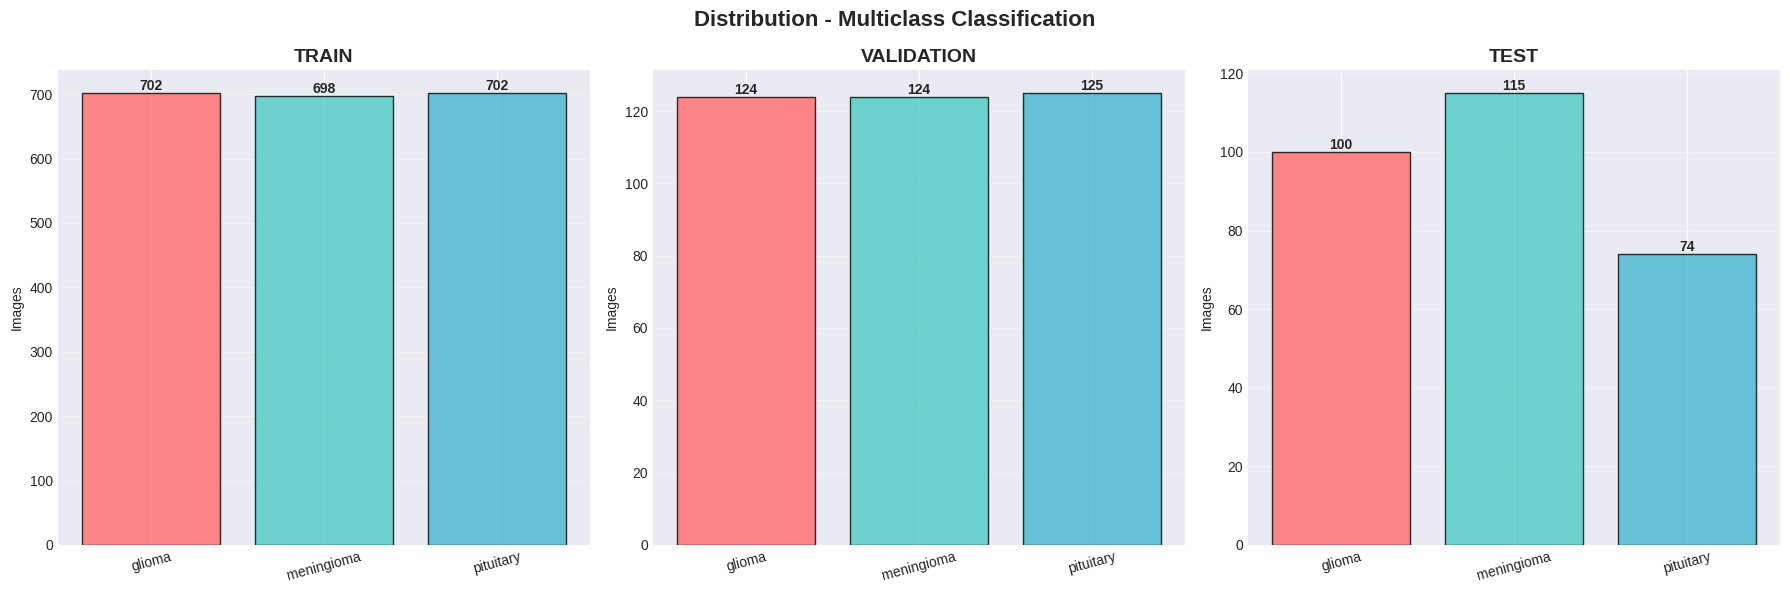


 BINARY CLASSIFICATION:
  train        / tumor     :  510 images
  train        / no_tumor  :  510 images
  validation   / tumor     :   90 images
  validation   / no_tumor  :   90 images
  test         / tumor     :  115 images
  test         / no_tumor  :  105 images

 MULTICLASS CLASSIFICATION:
  train        / glioma     :  702 images
  train        / meningioma :  698 images
  train        / pituitary  :  702 images
  validation   / glioma     :  124 images
  validation   / meningioma :  124 images
  validation   / pituitary  :  125 images
  test         / glioma     :  100 images
  test         / meningioma :  115 images
  test         / pituitary  :   74 images


In [ ]:
DATASET = path2
# Count
distribution = {'binary': {}, 'multiclass': {}}

for split in ['train', 'validation', 'test']:
    for class_name in ['tumor', 'no_tumor']:
        path = os.path.join(DATASET, 'binary_classification', split, class_name)
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        if split not in distribution['binary']:
            distribution['binary'][split] = {}
        distribution['binary'][split][class_name] = count

for split in ['train', 'validation', 'test']:
    for class_name in ['glioma', 'meningioma', 'pituitary']:
        path = os.path.join(DATASET, 'multiclass_classification', split, class_name)
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        if split not in distribution['multiclass']:
            distribution['multiclass'][split] = {}
        distribution['multiclass'][split][class_name] = count

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribution - Binary Classification', fontsize=16, fontweight='bold')

for idx, split in enumerate(['train', 'validation', 'test']):
    data = distribution['binary'][split]
    axes[idx].bar(data.keys(), data.values(), color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black')
    axes[idx].set_title(f'{split.upper()}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Images')
    axes[idx].grid(True, alpha=0.3, axis='y')

    for i, (k, v) in enumerate(data.items()):
        axes[idx].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Multi-class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribution - Multiclass Classification', fontsize=16, fontweight='bold')

for idx, split in enumerate(['train', 'validation', 'test']):
    data = distribution['multiclass'][split]
    axes[idx].bar(data.keys(), data.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8, edgecolor='black')
    axes[idx].set_title(f'{split.upper()}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Images')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=15)

    for i, (k, v) in enumerate(data.items()):
        axes[idx].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n BINARY CLASSIFICATION:")
for split in ['train', 'validation', 'test']:
    for class_name in ['tumor', 'no_tumor']:
        count = distribution['binary'][split][class_name]
        print(f"  {split:12s} / {class_name:10s}: {count:4d} images")

print("\n MULTICLASS CLASSIFICATION:")
for split in ['train', 'validation', 'test']:
    for class_name in ['glioma', 'meningioma', 'pituitary']:
        count = distribution['multiclass'][split][class_name]
        print(f"  {split:12s} / {class_name:11s}: {count:4d} images")

## DATA MODELLING

**Objectives of the Modeling Phase:**

The modeling phase aims to design, train, and compare several Deep Learning models to identify the most effective architecture for the classification of brain MRI images. In accordance with the CRISP-DM methodology, this phase directly builds upon the decisions made during data preparation.

Two modeling objectives are pursued:

 - Binary classification: distinguishing patients with a brain tumor (tumor) from those without a tumor (no_tumor).

 - Conditional multi-class classification: identifying the type of tumor (Glioma, Meningioma, or Pituitary) only when the presence of a tumor is detected.

This section focuses on the comparative study of Transfer Learning models, which are particularly well-suited to limited-size medical datasets.

**Transfer Learning and Medical Imaging**

Training a deep convolutional neural network from scratch requires a massive volume of data, which is rarely available in medical imaging. Transfer Learning involves leveraging pre-trained models on large datasets (such as ImageNet) to transfer the learned knowledge to a new task.

In medical imaging, this approach offers several advantages:

- Reduced training time.

- Improved model convergence.

- Enhanced performance despite a limited number of annotated images.

Numerous studies have shown that the initial layers of a CNN learn generic features (edges, textures), which are also useful for MRI images.

**Selected Models:**

Two reference architectures were selected: EfficientNetB0 and DenseNet121. This choice is based on their proven effectiveness in recent work in medical imaging.

**1. EfficientNetB0**

EfficientNet is based on a compound scaling principle, which simultaneously balances:

 - the network depth,
 - the layer width,
 - the image resolution.

EfficientNetB0 is the base version of this family, offering an excellent compromise between performance, number of parameters, and computational cost.

These characteristics make it a model particularly well-suited to resource-constrained environments and medical databases.

**2. DenseNet121**

 DenseNet121 belongs to the family of densely connected networks. Each layer receives as input the feature maps from all previous layers.

The main advantages of DenseNet121 are:
 - improved gradient propagation,
 - efficient feature reuse,
 - reduced risk of overfitting.

These properties are particularly valuable for detecting fine and complex structures, typical of MRI images.

**Training Strategies**

For each architecture, three Transfer Learning strategies were implemented to evaluate their impact on performance.

**Mode 1: Feature Extraction**

In this mode:

The weights of the pre-trained model are completely frozen.

Only the final layers (classifier) ​​are trained.

**Advantages**: Fast training, limited risk of overfitting.

**Limitations**: Restricted adaptation to the specific characteristics of MRI images.

This mode serves as a baseline for comparison.

**Mode 2: Full Fine-tuning**

In this mode:

All layers of the model are trained.

The pre-trained weights are used only for initialization.

**Advantages**: Complete adaptation to MRI data, maximum performance potential.

**Limitations**: Increased risk of overfitting, higher computational cost.

This strategy is relevant when the data is sufficiently diverse, particularly through data augmentation using diffusion models.

**Mode 3: Partial Fine-tuning**

Partial fine-tuning represents a compromise between the two previous approaches:

- The first (low-level) layers are frozen.

- The deeper layers are retrained.

**Advantages**: Preservation of generic features, targeted adaptation to specific tumor patterns, and better bias/variance trade-off.
 This approach is often considered most suitable in medical imaging.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers
import warnings
warnings.filterwarnings('ignore')

### **Configuration and Data Loading**

In [ ]:
# ImageDataGenerator
# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
BASE_PATH = path2

# Preprocessing: EfficientNet handles internal scaling,
# but we apply data augmentation to limit overfitting.
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

test_val_datagen = ImageDataGenerator() # No augmentation for val/test

# 1. Binary Generators
train_gen_bin = train_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'binary_classification/train'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')

val_gen_bin = test_val_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'binary_classification/validation'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

# 2. Multiclass Generators
train_gen_multi = train_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'multiclass_classification/train'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

val_gen_multi = test_val_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'multiclass_classification/validation'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

Found 1020 images belonging to 2 classes.
Found 180 images belonging to 2 classes.
Found 2102 images belonging to 3 classes.
Found 373 images belonging to 3 classes.


### **Building the EfficientNetB0 Transfer Learning Model**

In [ ]:
from tensorflow.keras.layers import Layer, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
import tensorflow.keras.backend as K
import tensorflow as tf

# Custom Attention Layer
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=-1)
        output = x * a
        return output

    def compute_output_shape(self, input_shape):
        return input_shape

def build_efficientnet_model_with_attention(num_classes, activation):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = AttentionLayer(name='attention_layer')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation=activation)(x)

    model = Model(inputs, outputs, name='EfficientNetB0_with_Attention')
    return model

### **Binary Classification Model (Feature Extraction):**

In [ ]:
# Model 1: Binary (Tumor vs No Tumor) WITH ATTENTION
model_bin = build_efficientnet_model_with_attention(1, 'sigmoid')
model_bin.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
history_bin = model_bin.fit(
    train_gen_bin,
    validation_data=val_gen_bin,
    epochs=10
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.5444 - loss: 0.6921 - precision: 0.6897 - recall: 0.1103 - val_accuracy: 0.8667 - val_loss: 0.6829 - val_precision: 0.8300 - val_recall: 0.9222
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 391ms/step - accuracy: 0.8139 - loss: 0.6787 - precision: 0.8308 - recall: 0.7941 - val_accuracy: 0.9000 - val_loss: 0.6455 - val_precision: 0.8830 - val_recall: 0.9222
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 389ms/step - accuracy: 0.8781 - loss: 0.6371 - precision: 0.9238 - recall: 0.8281 - val_accuracy: 0.9278 - val_loss: 0.5773 - val_precision: 0.9425 - val_recall: 0.9111
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 389ms/step - accuracy: 0.8900 - loss: 0.5696 - precision: 0.9532 - recall: 0.8264 - val_accuracy: 0.9389 - val_loss: 0.4955 - val_precision: 0.9438 - val_recall: 0.9333
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 384ms/step - accuracy: 0.8932 - loss: 0.4914 - precision: 0.9298 - recall: 0.8533 - val_accuracy: 0.9444 - val_loss: 

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, title="Training Evolution"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Accuracy Graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#2ecc71', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#e74c3c', marker='s')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Loss Graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#2ecc71', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#e74c3c', marker='s')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

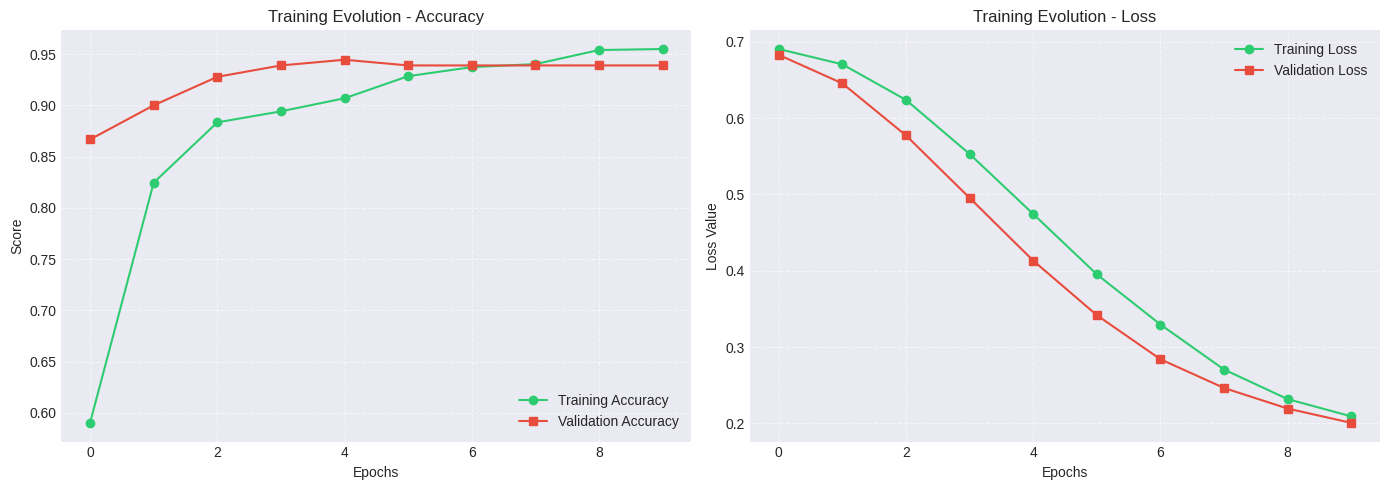

In [ ]:
# loss and Accuracy curves
plot_training_history(history_bin, title="Training Evolution")

In [ ]:
# Evaluation and Confusion Matrix

def evaluate_and_plot(model, generator, labels, title):
    # Predictions
    preds = model.predict(generator)
    if len(labels) == 2: # Binary case
        y_pred = (preds > 0.5).astype(int).flatten()
    else: # Multi-class case
        y_pred = np.argmax(preds, axis=1)

    y_true = generator.classes

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Classification Report (Precision, Recall, F1)
    print(f"--- Classification Report: {title} ---")
    print(classification_report(y_true, y_pred, target_names=labels))

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


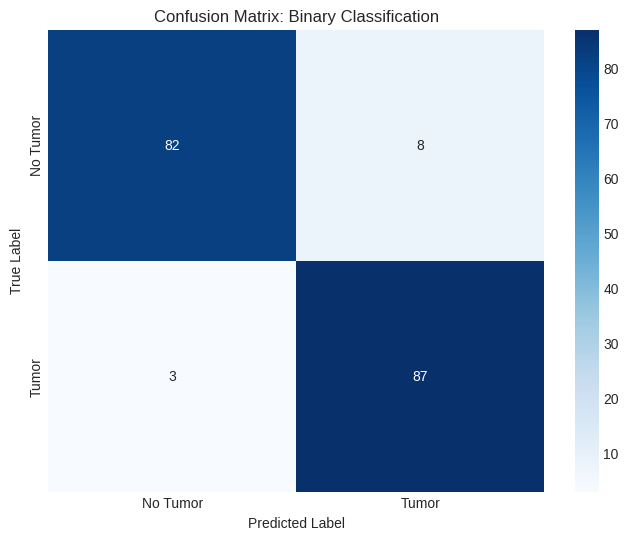

--- Classification Report: Binary Classification ---
              precision    recall  f1-score   support

    No Tumor       0.96      0.91      0.94        90
       Tumor       0.92      0.97      0.94        90

    accuracy                           0.94       180
   macro avg       0.94      0.94      0.94       180
weighted avg       0.94      0.94      0.94       180



In [ ]:
# Display for binary classification
evaluate_and_plot(model_bin, val_gen_bin, ['No Tumor', 'Tumor'], "Binary Classification")

In [ ]:
def visualize_attention_weights(model, image_path, true_label):
    """
    Visualize what the attention mechanism focuses on
    """
    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # Create a model that outputs attention weights
    attention_model = Model(
        inputs=model.input,
        outputs=model.get_layer('attention_layer').output
    )

    # Get attention weights
    attention_output = attention_model.predict(img_array, verbose=0)

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Original image
    axes[0].imshow(img)
    axes[0].set_title(f'Original Image\nTrue Label: {true_label}')
    axes[0].axis('off')

    # Attention heatmap
    attention_weights = attention_output[0]

    axes[1].bar(range(len(attention_weights)), attention_weights)
    axes[1].set_title('Attention Weights Distribution')
    axes[1].set_xlabel('Feature Index')
    axes[1].set_ylabel('Attention Weight')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Make prediction
    pred = model.predict(img_array, verbose=0)
    return pred, attention_weights


ANTE-HOC EXPLAINABILITY: Attention Visualization

TUMOR IMAGE ATTENTION:


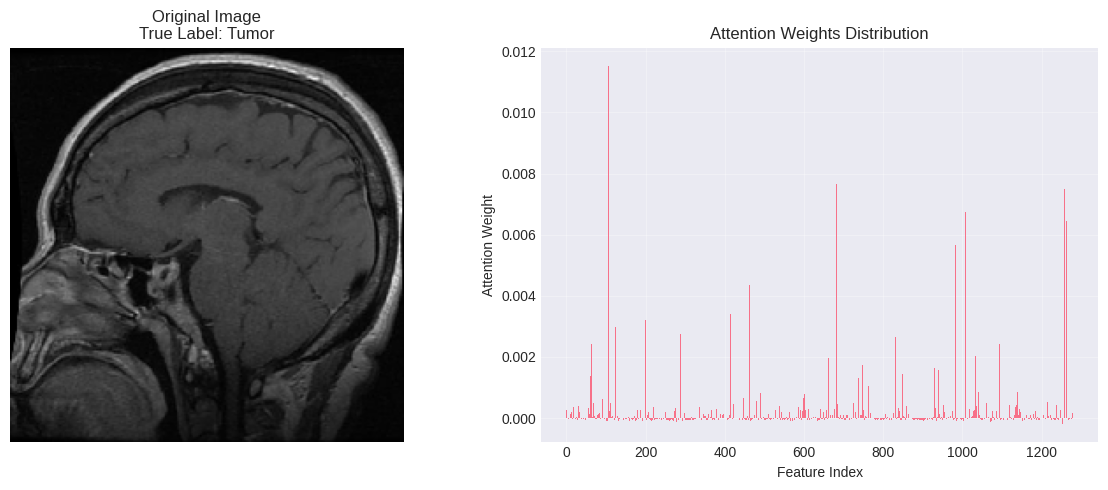

Prediction: Tumor (confidence: 0.9252)

NO TUMOR IMAGE ATTENTION:


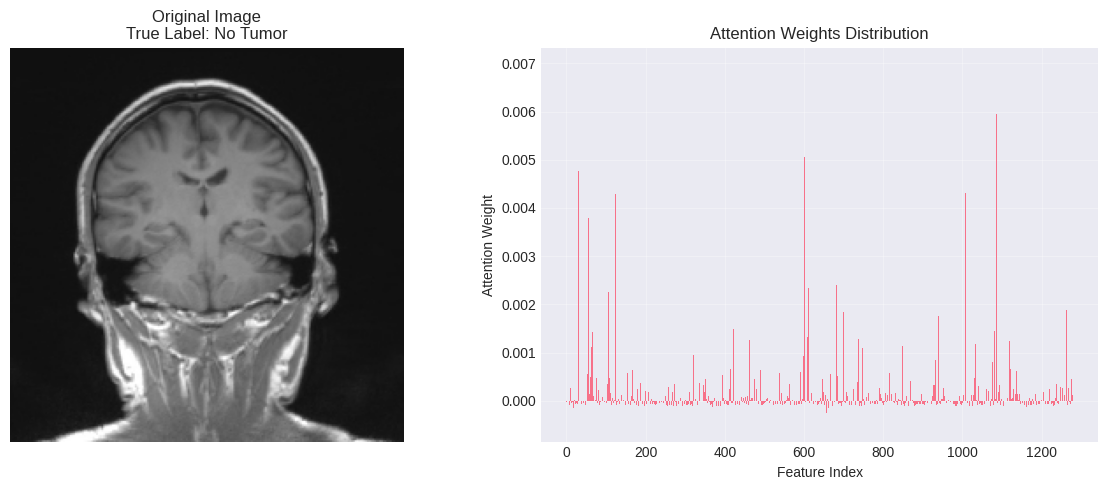

Prediction: No Tumor (confidence: 0.4091)


In [ ]:
# Visualize attention for sample images
print("\n" + "="*80)
print("ANTE-HOC EXPLAINABILITY: Attention Visualization")
print("="*80 + "\n")

# Get a sample tumor image
sample_tumor_path = os.path.join(path2, 'binary_classification', 'validation', 'tumor')
tumor_images = [f for f in os.listdir(sample_tumor_path) if f.endswith(('.jpg', '.png'))]
sample_tumor = os.path.join(sample_tumor_path, tumor_images[0])

# Get a sample no_tumor image
sample_notumor_path = os.path.join(path2, 'binary_classification', 'validation', 'no_tumor')
notumor_images = [f for f in os.listdir(sample_notumor_path) if f.endswith(('.jpg', '.png'))]
sample_notumor = os.path.join(sample_notumor_path, notumor_images[0])

print("TUMOR IMAGE ATTENTION:")
pred, attn = visualize_attention_weights(model_bin, sample_tumor, 'Tumor')
print(f"Prediction: {'Tumor' if pred[0][0] > 0.5 else 'No Tumor'} (confidence: {pred[0][0]:.4f})\n")

print("NO TUMOR IMAGE ATTENTION:")
pred, attn = visualize_attention_weights(model_bin, sample_notumor, 'No Tumor')
print(f"Prediction: {'Tumor' if pred[0][0] > 0.5 else 'No Tumor'} (confidence: {pred[0][0]:.4f})")

In [ ]:
model_bin.save('model_bin.h5')

### **Multi-class Classification Model (Feature Extraction):**

In [ ]:
# Model 2: Multi-class (Glioma, Meningioma, Pituitary) WITH ATTENTION
model_multi = build_efficientnet_model_with_attention(3, 'softmax')
model_multi.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

In [ ]:
# Training the multi-class model
history_multi = model_multi.fit(
    train_gen_multi,
    validation_data=val_gen_multi,
    epochs=10
)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 81s 916ms/step - accuracy: 0.3984 - loss: 1.0941 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.5389 - val_loss: 1.0544 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 417ms/step - accuracy: 0.6330 - loss: 1.0149 - precision_1: 0.3943 - recall_1: 0.0083 - val_accuracy: 0.6059 - val_loss: 0.8860 - val_precision_1: 0.8760 - val_recall_1: 0.3029
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 25s 383ms/step - accuracy: 0.6475 - loss: 0.8294 - precision_1: 0.8919 - recall_1: 0.2897 - val_accuracy: 0.6568 - val_loss: 0.7277 - val_precision_1: 0.7796 - val_recall_1: 0.3887
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 389ms/step - accuracy: 0.6936 - loss: 0.7034 - precision_1: 0.7861 - recall_1: 0.4411 - val_accuracy: 0.6756 - val_loss: 0.6717 - val_precision_1: 0.7621 - val_recall_1: 0.5067
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 387ms/step - accuracy: 0.7025 - loss: 0.6309 - precision_1: 0.7551

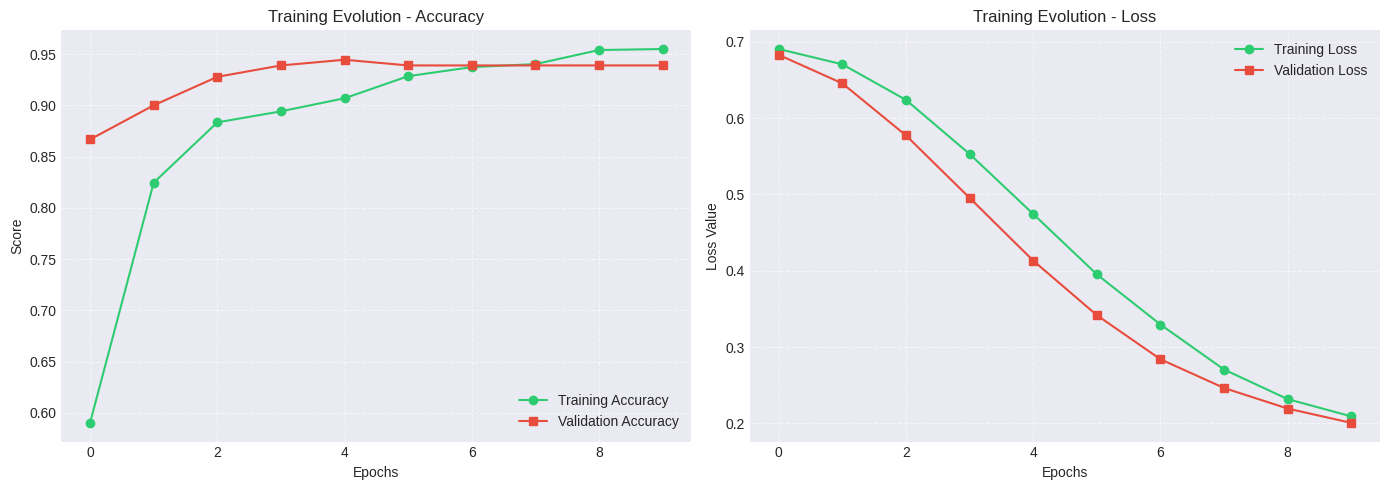

In [ ]:
# Loss and Accuracy curves
plot_training_history(history_bin, title="Training Evolution")

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 769ms/step


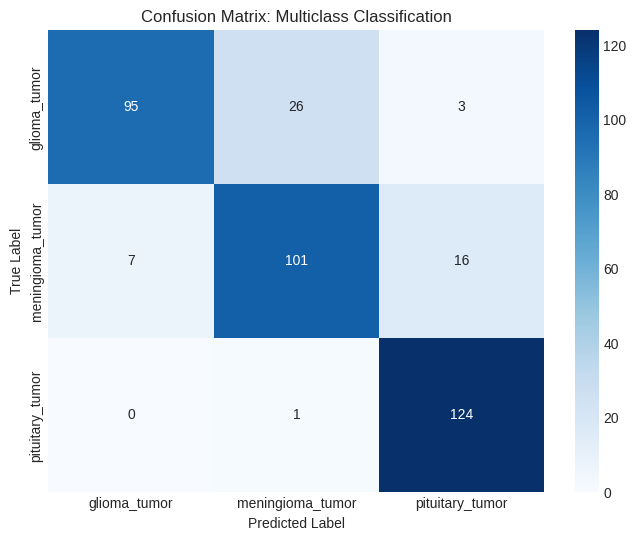

--- Classification Report: Multiclass Classification ---
                  precision    recall  f1-score   support

    glioma_tumor       0.93      0.77      0.84       124
meningioma_tumor       0.79      0.81      0.80       124
 pituitary_tumor       0.87      0.99      0.93       125

        accuracy                           0.86       373
       macro avg       0.86      0.86      0.86       373
    weighted avg       0.86      0.86      0.86       373



In [ ]:
# Evaluate the multi-class classification model
evaluate_and_plot(model_multi, val_gen_multi, ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor'], "Multiclass Classification")

In [ ]:
# Visualize attention for multi-class samples
print("\n" + "="*80)
print("MULTI-CLASS ATTENTION VISUALIZATION")
print("="*80 + "\n")

# Get sample images from each tumor type
tumor_types = ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']

for tumor_type in tumor_types:
    sample_path = os.path.join(path2, 'multiclass_classification', 'validation', tumor_type)
    images = [f for f in os.listdir(sample_path) if f.endswith(('.jpg', '.png'))]
    sample_image = os.path.join(sample_path, images[0])

    print(f"\n{tumor_type.upper().replace('_', ' ')}:")
    pred, attn = visualize_attention_weights(model_multi, sample_image, tumor_type)
    predicted_class = ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor'][np.argmax(pred[0])]
    confidence = np.max(pred[0])
    print(f"Prediction: {predicted_class} (confidence: {confidence:.4f})")


MULTI-CLASS ATTENTION VISUALIZATION



FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/sofienehermi/brain-tumor-balanced/versions/1/multiclass_classification/validation/glioma_tumor'

### **Total fine-tuning for the multi-class model**

In [ ]:
# Unfreeze the base model
def build_efficientnet_model(num_classes, activation):
    # Load the EfficientNetB0 base pre-trained on ImageNet
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = True  # Unfreeze weights initially

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(rate=0.2),
        layers.Dense(num_classes, activation=activation)
    ])

    return model

In [ ]:
# Model 3: Multi-class (Glioma, Meningioma, Pituitary) with Fine Tuning
model_multi_fine = build_efficientnet_model(3, 'softmax')
model_multi_fine.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

In [ ]:
callbacks = [
    # Stops training if validation loss does not decrease for 3 epochs
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    # Reduces LR if the model plateaus
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7)
]

In [ ]:
# Launching Fine-tuning
history_fine = model_multi_fine.fit(
    train_gen_multi,
    validation_data=val_gen_multi,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.5716 - loss: 1.0616 - precision_2: 0.5964 - recall_2: 0.5249 - val_accuracy: 0.8391 - val_loss: 0.4406 - val_precision_2: 0.8496 - val_recall_2: 0.8177 - learning_rate: 1.0000e-05
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 452ms/step - accuracy: 0.8035 - loss: 0.4717 - precision_2: 0.8155 - recall_2: 0.7866 - val_accuracy: 0.8767 - val_loss: 0.3287 - val_precision_2: 0.8846 - val_recall_2: 0.8633 - learning_rate: 1.0000e-05
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 464ms/step - accuracy: 0.8606 - loss: 0.3733 - precision_2: 0.8676 - recall_2: 0.8444 - val_accuracy: 0.8928 - val_loss: 0.3161 - val_precision_2: 0.8916 - val_recall_2: 0.8820 - learning_rate: 1.0000e-05
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 448ms/step - accuracy: 0.8821 - loss: 0.3130 - precision_2: 0.8912 - recall_2: 0.8723 - val_accuracy: 0.8820 - val_loss: 0.3023 - val_precision_2: 0.8889 - val_recall_2: 0.8794 - learning_rate: 1.0000e-05
Epoch 5/10
66/

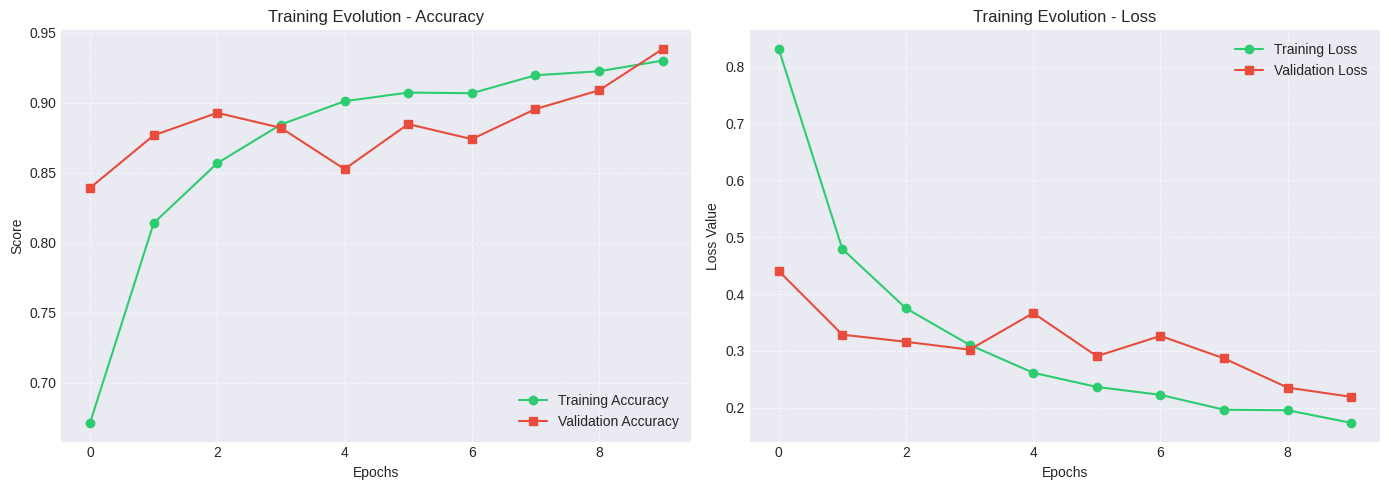

In [ ]:
plot_training_history(history_fine, title="Training Evolution")

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 661ms/step


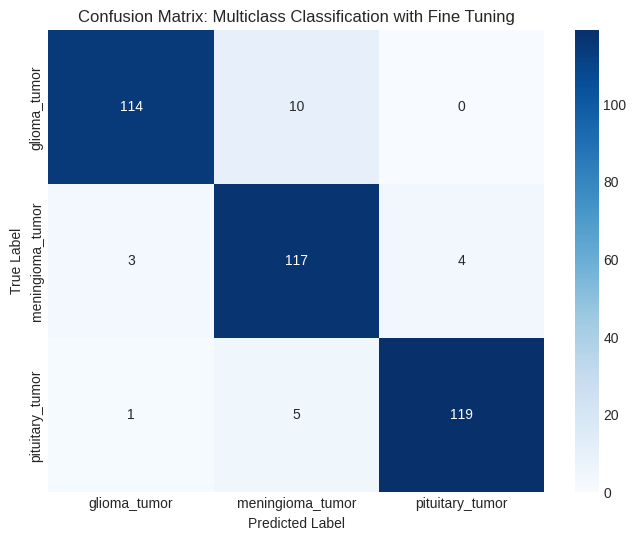

--- Classification Report: Multiclass Classification with Fine Tuning ---
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.92      0.94       124
meningioma_tumor       0.89      0.94      0.91       124
 pituitary_tumor       0.97      0.95      0.96       125

        accuracy                           0.94       373
       macro avg       0.94      0.94      0.94       373
    weighted avg       0.94      0.94      0.94       373



In [ ]:
# Evaluation and Confusion Matrix
# Display for multiclass
evaluate_and_plot(model_multi_fine, val_gen_multi, ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor'], "Multiclass Classification with Fine Tuning")

### **Partial fine-tuning for the multi-class model**



In [ ]:
# Unfreeze the base model
def build_efficientnet_model(num_classes, activation):
    # Load the EfficientNetB0 base pre-trained on ImageNet
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # We chose to train 78 layers,
    # meaning we will freeze
    # the first 160 layers and unfreeze the rest:
    for layer in base_model.layers[:160]:
        layer.trainable = False
    for layer in base_model.layers[160:]:
        layer.trainable = True

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(rate=0.2),
        layers.Dense(num_classes, activation=activation)
    ])

    return model

In [ ]:
# Model 3: Multi-class (Glioma, Meningioma, Pituitary) with Fine Tuning
model_multi_fine = build_efficientnet_model(3, 'softmax')
model_multi_fine.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

In [ ]:
callbacks = [
    # Stops training if validation loss does not decrease for 3 epochs
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    # Reduces LR if the model plateaus
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7)
]

In [ ]:
# Launching Fine-tuning
history_fine = model_multi_fine.fit(
    train_gen_multi,
    validation_data=val_gen_multi,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 95s 895ms/step - accuracy: 0.5558 - loss: 1.0828 - precision_3: 0.5737 - recall_3: 0.5048 - val_accuracy: 0.7587 - val_loss: 0.5344 - val_precision_3: 0.7837 - val_recall_3: 0.7480 - learning_rate: 1.0000e-05
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 434ms/step - accuracy: 0.7993 - loss: 0.5080 - precision_3: 0.8166 - recall_3: 0.7845 - val_accuracy: 0.8499 - val_loss: 0.3931 - val_precision_3: 0.8529 - val_recall_3: 0.8391 - learning_rate: 1.0000e-05
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 439ms/step - accuracy: 0.8258 - loss: 0.4409 - precision_3: 0.8351 - recall_3: 0.8182 - val_accuracy: 0.8713 - val_loss: 0.3222 - val_precision_3: 0.8822 - val_recall_3: 0.8633 - learning_rate: 1.0000e-05
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 431ms/step - accuracy: 0.8846 - loss: 0.3012 - precision_3: 0.8958 - recall_3: 0.8771 - val_accuracy: 0.8901 - val_loss: 0.2768 - val_precision_3: 0.8943 - val_recall_3: 0.8847 - learning_rate: 1.0000e-05
Epoch 5/10
6

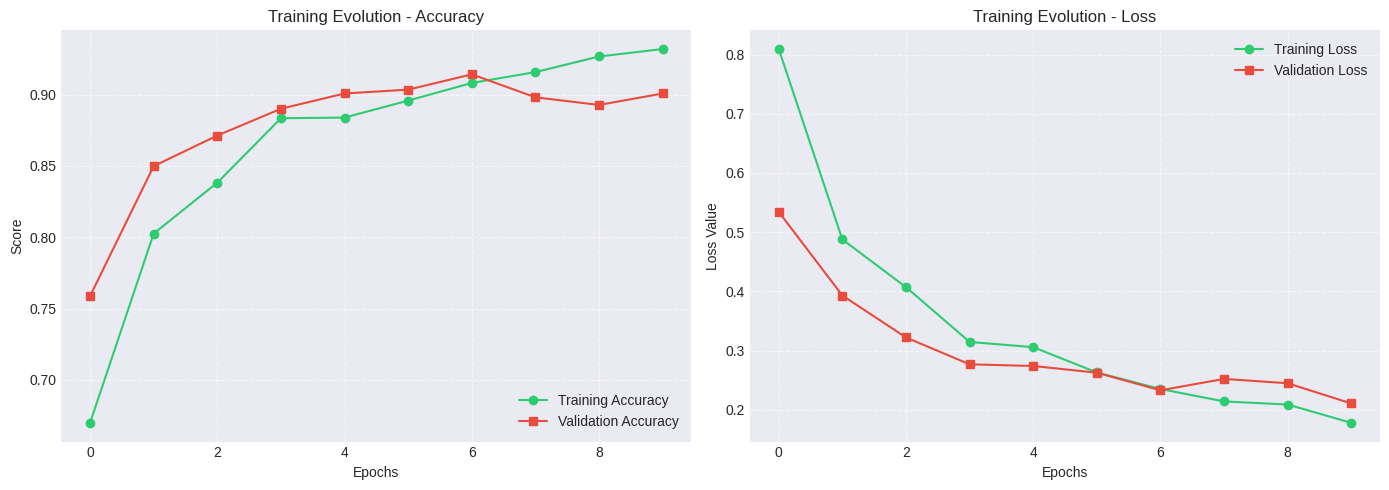

In [ ]:
plot_training_history(history_fine, title="Training Evolution")

12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 733ms/step


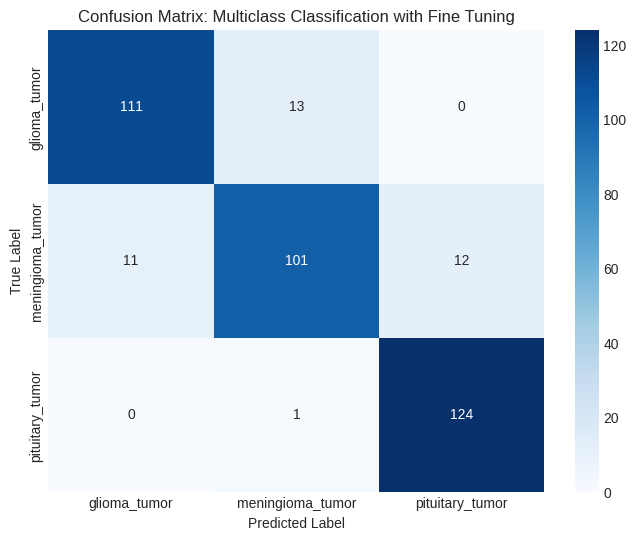

--- Classification Report: Multiclass Classification with Fine Tuning ---
                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.90      0.90       124
meningioma_tumor       0.88      0.81      0.85       124
 pituitary_tumor       0.91      0.99      0.95       125

        accuracy                           0.90       373
       macro avg       0.90      0.90      0.90       373
    weighted avg       0.90      0.90      0.90       373



In [ ]:
# Evaluation and Confusion Matrix
# Display for multiclass
evaluate_and_plot(model_multi_fine, val_gen_multi, ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor'], "Multiclass Classification with Fine Tuning")

In [ ]:
model_multi_fine.save('model_multi_fine_partial.h5') # Saving the multiclass model

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for array operations

# Final decision pipeline

def diagnostic_pipeline(image_path, model_bin, model_multi_fine):
    # 1. Load and prepare the image
    # Load image in grayscale and resize
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return "Error: Could not load image."

    # Resize to 224x224 as required by the model input_shape
    img_resized = cv2.resize(img, (224, 224))

    print(f"Original image path: {image_path}")
    print(f"Resized 2D pixel matrix shape: {img_resized.shape}")

    # Display the processed image
    plt.figure(figsize=(4, 4))
    plt.imshow(img_resized, cmap='gray')
    plt.title('Processed Image (224x224 grayscale)')
    plt.axis('off')
    plt.show()

    # Print a sample of the 2D pixel matrix from a different region (e.g., center)
    print("Sample of the original 2D pixel matrix (center 5x5):")
    print(img_resized[100:105, 100:105]) # Showing pixels from row 100-104, col 100-104

    # --- Demonstrate Scaling ---
    # 1. Scale to 0-1 range
    img_scaled_0_1 = img_resized.astype(np.float32) / 255.0
    print("\nSample of the 2D pixel matrix (center 5x5, scaled 0-1):")
    print(img_scaled_0_1[100:105, 100:105])

    # 2. Scale to -1 to 1 range
    img_scaled_minus1_1 = (img_scaled_0_1 * 2) - 1
    print("\nSample of the 2D pixel matrix (center 5x5, scaled -1 to 1):")
    print(img_scaled_minus1_1[100:105, 100:105])
    # --- End Scaling Demonstration ---

    # Convert to a 1D matrix (flatten) - this step is for demonstration, not direct model input
    img_flattened = img_resized.flatten()
    print(f"\nFlattened 1D pixel matrix shape: {img_flattened.shape}")

    # Convert to 3-channel for EfficientNet (duplicate grayscale to R, G, B)
    # The model expects input in a certain range, which is handled by EfficientNet itself or prior normalization.
    # For this model, we typically use the 0-1 or -1 to 1 range, depending on how it was pre-trained/fine-tuned.
    # EfficientNet models often include their own internal preprocessing or expect 0-255 which they then scale.
    # Assuming the previous models were trained with `ImageDataGenerator` which usually scales to 0-255 or 0-1 implicitly,
    # we will use the img_scaled_0_1 for the 3-channel conversion to align with common practices for these models.
    # However, the `ImageDataGenerator` in our setup didn't explicitly scale to 0-1 for EfficientNet, it only handled augmentation.
    # EfficientNetB0's weights are pre-trained on ImageNet, which expects input in the range [0, 255] or [0, 1] depending on its specific preprocessing function.
    # Keras Applications models usually have a `preprocess_input` function.
    # Let's revert to using the original resized image and let the model handle scaling or assume it's expecting 0-255.
    # For accurate demonstration of scaling, we will print the values, but the actual input to the model should match its training.
    # For EfficientNetB0 from `tf.keras.applications`, the `preprocess_input` usually handles this.
    # Here, for the diagnostic pipeline, the original img_resized (0-255) is converted to 3-channel.
    img_array = np.stack([img_resized, img_resized, img_resized], axis=-1)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    # 2. Step 1: Tumor detection (Binary)
    is_tumor_prob = model_bin.predict(img_array)[0][0]

    if is_tumor_prob < 0.5:
        return "Result: No tumor detected."
    else:
        # 3. Step 2: If tumor, classify the type (Multi-class)
        type_preds = model_multi_fine.predict(img_array)
        classes_multi = ['Glioma', 'Meningioma', 'Pituitary']
        detected_type = classes_multi[np.argmax(type_preds)]
        return f"Result: Tumor detected. Suspected type: {detected_type} (Confidence: {np.max(type_preds)*100:.2f}%)"


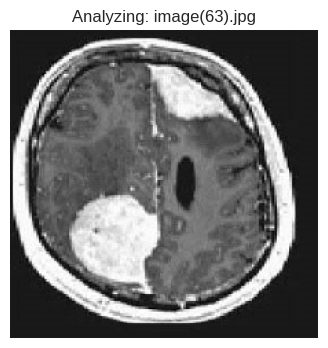

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Result: Tumor detected. Suspected type: Meningioma (Confidence: 75.02%)


In [ ]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import random
import os
import numpy as np
import tensorflow as tf

def get_random_test_image(base_path, classification_type='multiclass_classification'):
    test_dir = os.path.join(base_path, classification_type, 'test')
    image_paths = []
    for class_name in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(class_path, img_name))
    return random.choice(image_paths) if image_paths else None

def diagnostic_pipeline(image_path, model_bin, model_multi):
    # 1. Load and prepare the image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Display the image
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Analyzing: {os.path.basename(image_path)}")
    plt.axis('off')
    plt.show()

    # 2. Step 1: Tumor detection (Binary)
    is_tumor_prob = model_bin.predict(img_array)[0][0]

    if is_tumor_prob < 0.5:
        return "Result: No tumor detected."
    else:
        # 3. Step 2: If tumor, classify the type (Multi-class)
        type_preds = model_multi.predict(img_array)
        classes_multi = ['Glioma', 'Meningioma', 'Pituitary']
        detected_type = classes_multi[np.argmax(type_preds)]
        return f"Result: Tumor detected. Suspected type: {detected_type} (Confidence: {np.max(type_preds)*100:.2f}%)"

# Use the function that successfully gets a random test image path from the correct dataset location
test_img_path = get_random_test_image(path2)

if test_img_path:
    binary_model = load_model('/content/model_bin.h5')
    binary_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

    multi_model = load_model('/content/model_multi_fine_partial.h5')
    multi_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

    print(diagnostic_pipeline(test_img_path, binary_model, multi_model))
else:
    print("No test images found to proceed with diagnostic pipeline.")


## **Construction of the transfer learning model DenseNet121**

In [ ]:
from tensorflow.keras.applications import DenseNet121

def build_densenet_model(num_classes, activation):
    # Load pre-trained DenseNet121
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False # Freeze for initial transfer

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(rate=0.2),
        layers.Dense(num_classes, activation=activation)
    ])

    return model

### **Binary Model with DenseNet121**

In [ ]:
# Create the binary model
model_bin_dense = build_densenet_model(1, 'sigmoid')
model_bin_dense.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
history_bin_dense = model_bin_dense.fit(
    train_gen_bin,
    validation_data=val_gen_bin,
    epochs=10
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.6715 - loss: 43.4068 - precision_8: 0.6921 - recall_8: 0.6269 - val_accuracy: 0.8667 - val_loss: 4.3044 - val_precision_8: 0.8235 - val_recall_8: 0.9333
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 445ms/step - accuracy: 0.8340 - loss: 5.5628 - precision_8: 0.8515 - recall_8: 0.8222 - val_accuracy: 0.8722 - val_loss: 3.5630 - val_precision_8: 0.9589 - val_recall_8: 0.7778
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 446ms/step - accuracy: 0.8464 - loss: 3.7100 - precision_8: 0.8728 - recall_8: 0.8291 - val_accuracy: 0.8167 - val_loss: 2.3386 - val_precision_8: 0.7355 - val_recall_8: 0.9889
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 477ms/step - accuracy: 0.8840 - loss: 1.5623 - precision_8: 0.8685 - recall_8: 0.9123 - val_accuracy: 0.9167 - val_loss: 0.2975 - val_precision_8: 0.8788 - val_recall_8: 0.9667
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 440ms/step - accuracy: 0.9274 - loss: 0.2673 - precision_8: 0.9166 - recall_8: 0.934

In [ ]:
model_bin_dense.save('model_bin_dense.h5') # Saving the binary model

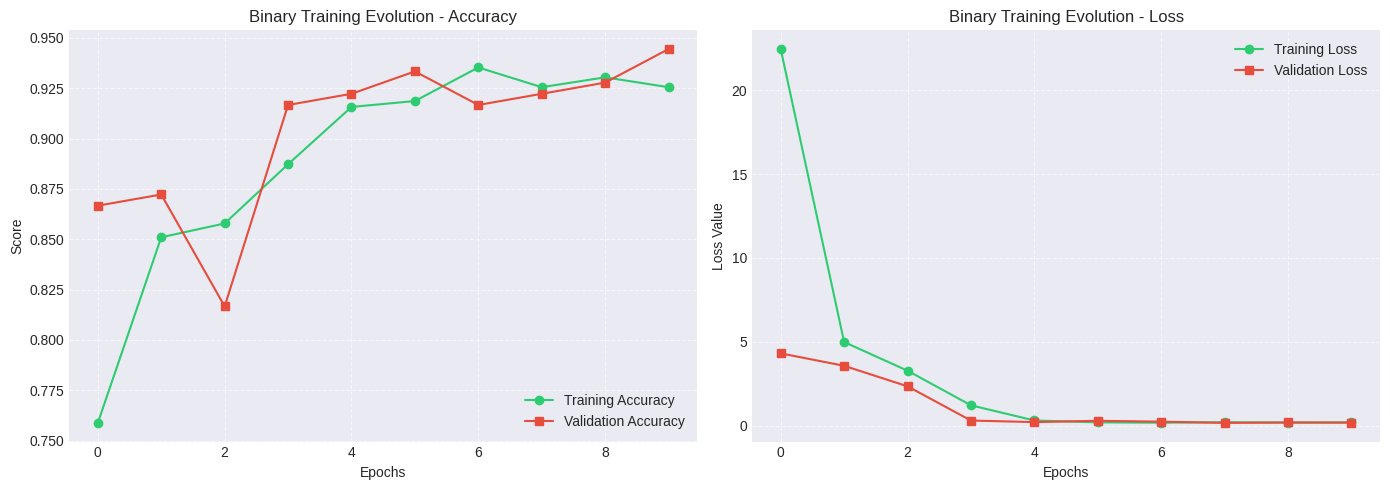

In [ ]:
# Loss and Accuracy curves
plot_training_history(history_bin_dense, title="Binary Training Evolution")

6/6 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step


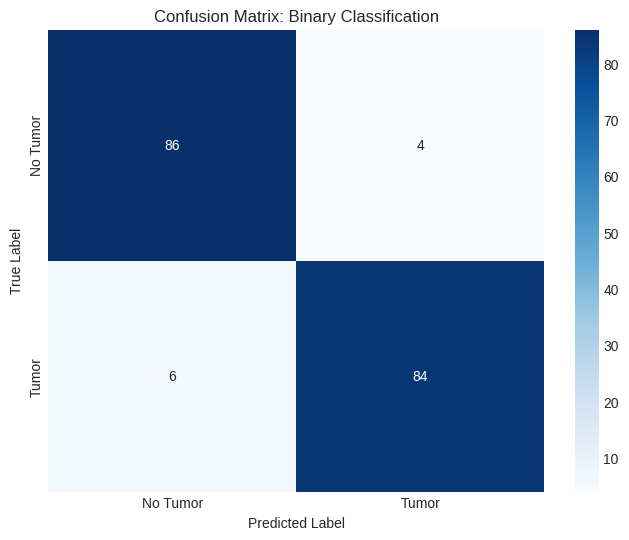

--- Classification Report: Binary Classification ---
              precision    recall  f1-score   support

    No Tumor       0.93      0.96      0.95        90
       Tumor       0.95      0.93      0.94        90

    accuracy                           0.94       180
   macro avg       0.94      0.94      0.94       180
weighted avg       0.94      0.94      0.94       180



In [ ]:
# Display for binary
evaluate_and_plot(model_bin_dense, val_gen_bin, ['No Tumor', 'Tumor'], "Binary Classification")

### **Multi-class model with DenseNet121 (feature extraction)**

In [ ]:
# Create the multi-class model
model_multi_dense = build_densenet_model(3, 'softmax')
model_multi_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

In [ ]:
# Training the multi-class model
history_multi_dense = model_multi_dense.fit(
    train_gen_multi,
    validation_data=val_gen_multi,
    epochs=10
)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.5159 - loss: 55.3571 - precision_9: 0.5158 - recall_9: 0.5155 - val_accuracy: 0.7534 - val_loss: 0.7224 - val_precision_9: 0.7547 - val_recall_9: 0.7507
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 448ms/step - accuracy: 0.7018 - loss: 0.7423 - precision_9: 0.7340 - recall_9: 0.6644 - val_accuracy: 0.7882 - val_loss: 0.5863 - val_precision_9: 0.8144 - val_recall_9: 0.7292
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 447ms/step - accuracy: 0.7798 - loss: 0.5229 - precision_9: 0.8075 - recall_9: 0.7340 - val_accuracy: 0.7426 - val_loss: 0.5830 - val_precision_9: 0.7708 - val_recall_9: 0.7212
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 440ms/step - accuracy: 0.7962 - loss: 0.4740 - precision_9: 0.8190 - recall_9: 0.7708 - val_accuracy: 0.7587 - val_loss: 0.5003 - val_precision_9: 0.8053 - val_recall_9: 0.7319
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 456ms/step - accuracy: 0.7731 - loss: 0.5304 - precision_9: 0.7956 - recall_9: 0.735

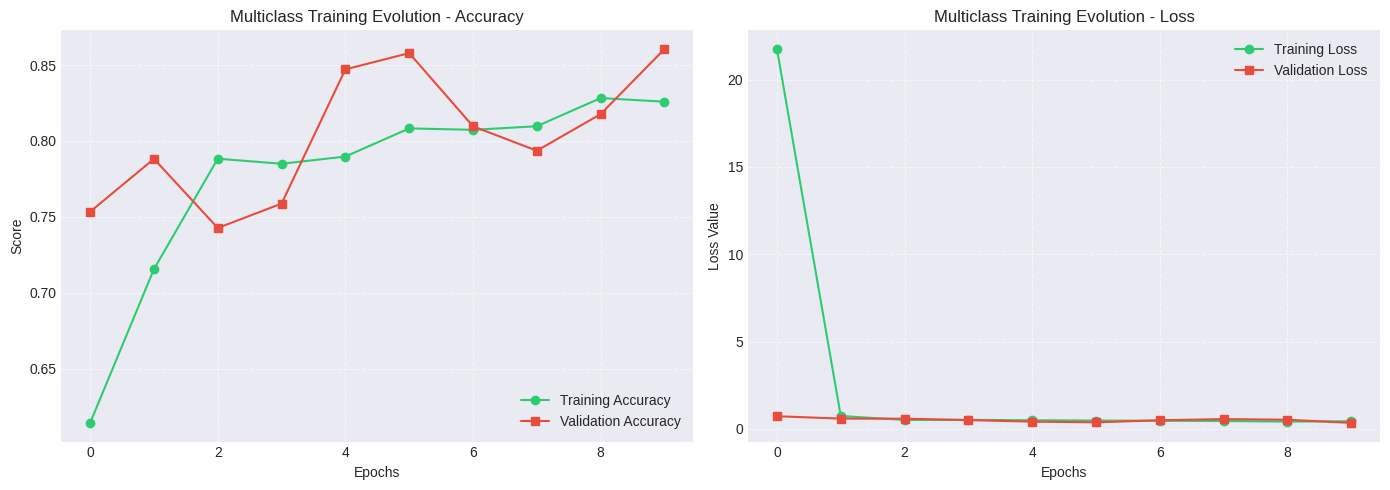

In [ ]:
# Loss and Accuracy curves
plot_training_history(history_multi_dense, title="Multiclass Training Evolution")

12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step


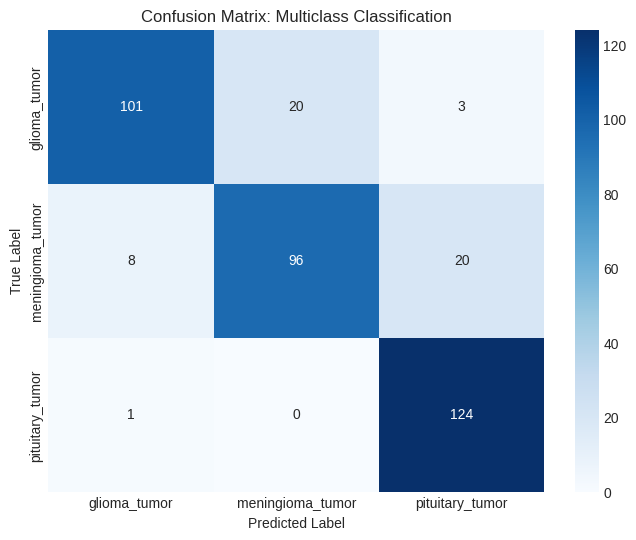

--- Classification Report: Multiclass Classification ---
                  precision    recall  f1-score   support

    glioma_tumor       0.92      0.81      0.86       124
meningioma_tumor       0.83      0.77      0.80       124
 pituitary_tumor       0.84      0.99      0.91       125

        accuracy                           0.86       373
       macro avg       0.86      0.86      0.86       373
    weighted avg       0.86      0.86      0.86       373



In [ ]:
# Evaluation and Confusion Matrix
# Display for multiclass
evaluate_and_plot(model_multi_dense, val_gen_multi, ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor'], "Multiclass Classification")

In [ ]:
# Final decision pipeline

def diagnostic_pipeline(image_path, model_bin, model_multi):
    # 1. Load and prepare the image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Step 1: Tumor detection (Binary)
    is_tumor_prob = model_bin.predict(img_array)[0][0]

    if is_tumor_prob < 0.5:
        return "Result: No tumor detected."
    else:
        # 3. Step 2: If tumor, classify the type (Multi-class)
        type_preds = model_multi.predict(img_array)
        classes_multi = ['Glioma', 'Meningioma', 'Pituitary']
        detected_type = classes_multi[np.argmax(type_preds)]
        return f"Result: Tumor detected. Suspected type: {detected_type} (Confidence: {np.max(type_preds)*100:.2f}%)"

In [ ]:
import random

def get_random_test_image(base_path, classification_type='multiclass_classification'):
    test_dir = os.path.join(base_path, classification_type, 'test')
    image_paths = []
    for class_name in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(class_path, img_name))
    return random.choice(image_paths) if image_paths else None

test_img_path = get_random_test_image(path2)

if test_img_path:
    # Load the DenseNet121 models
    binary_model_densenet = model_bin_dense # Already loaded and trained in a previous cell
    multi_model_densenet = model_multi_dense # Already loaded and trained in a previous cell

    print(f"Predicting for random image: {test_img_path}")
    print(diagnostic_pipeline(test_img_path, binary_model_densenet, multi_model_densenet))
else:
    print("No test images found to predict.")


Predicting for random image: /kaggle/input/brain-tumor-balanced/multiclass_classification/test/glioma/image(9).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Result: Tumor detected. Suspected type: Meningioma (Confidence: 53.57%)


In [ ]:
print("\n--- EfficientNetB0 Binary Classification Metrics ---")
print(f"Training Accuracy: {history_bin.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history_bin.history['val_accuracy'][-1]:.4f}")
print(f"Training Precision: {history_bin.history['precision'][-1]:.4f}")
print(f"Validation Precision: {history_bin.history['val_precision'][-1]:.4f}")
print(f"Training Recall: {history_bin.history['recall'][-1]:.4f}")
print(f"Validation Recall: {history_bin.history['val_recall'][-1]:.4f}")

print("\n--- EfficientNetB0 Multi-class Classification (Feature Extraction) Metrics ---")
print(f"Training Accuracy: {history_multi.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history_multi.history['val_accuracy'][-1]:.4f}")
print(f"Training Precision: {history_multi.history['precision_1'][-1]:.4f}")
print(f"Validation Precision: {history_multi.history['val_precision_1'][-1]:.4f}")
print(f"Training Recall: {history_multi.history['recall_1'][-1]:.4f}")
print(f"Validation Recall: {history_multi.history['val_recall_1'][-1]:.4f}")

print("\n--- EfficientNetB0 Multi-class Classification (Partial Fine-tuning) Metrics ---")
print(f"Training Accuracy: {history_fine.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history_fine.history['val_accuracy'][-1]:.4f}")
print(f"Training Precision: {history_fine.history['precision_3'][-1]:.4f}")
print(f"Validation Precision: {history_fine.history['val_precision_3'][-1]:.4f}")
print(f"Training Recall: {history_fine.history['recall_3'][-1]:.4f}")
print(f"Validation Recall: {history_fine.history['val_recall_3'][-1]:.4f}")

# Helper function to get dynamic metric keys
def get_metric_key(history_dict, metric_name_prefix):
    keys = [key for key in history_dict.keys() if key.startswith(metric_name_prefix) and not key.startswith('val_')]
    return keys[0] if keys else None

def get_val_metric_key(history_dict, metric_name_prefix):
    keys = [key for key in history_dict.keys() if key.startswith('val_' + metric_name_prefix)]
    return keys[0] if keys else None

# Dynamically get keys for DenseNet121 Binary Classification
precision_key_bin_dense = get_metric_key(history_bin_dense.history, 'precision')
recall_key_bin_dense = get_metric_key(history_bin_dense.history, 'recall')
val_precision_key_bin_dense = get_val_metric_key(history_bin_dense.history, 'precision')
val_recall_key_bin_dense = get_val_metric_key(history_bin_dense.history, 'recall')

print("\n--- DenseNet121 Binary Classification Metrics ---")
print(f"Training Accuracy: {history_bin_dense.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history_bin_dense.history['val_accuracy'][-1]:.4f}")
if precision_key_bin_dense and val_precision_key_bin_dense:
    print(f"Training Precision: {history_bin_dense.history[precision_key_bin_dense][-1]:.4f}")
    print(f"Validation Precision: {history_bin_dense.history[val_precision_key_bin_dense][-1]:.4f}")
if recall_key_bin_dense and val_recall_key_bin_dense:
    print(f"Training Recall: {history_bin_dense.history[recall_key_bin_dense][-1]:.4f}")
    print(f"Validation Recall: {history_bin_dense.history[val_recall_key_bin_dense][-1]:.4f}")

# Dynamically get keys for DenseNet121 Multi-class Classification
precision_key_multi_dense = get_metric_key(history_multi_dense.history, 'precision')
recall_key_multi_dense = get_metric_key(history_multi_dense.history, 'recall')
val_precision_key_multi_dense = get_val_metric_key(history_multi_dense.history, 'precision')
val_recall_key_multi_dense = get_val_metric_key(history_multi_dense.history, 'recall')

print("\n--- DenseNet121 Multi-class Classification (Feature Extraction) Metrics ---")
print(f"Training Accuracy: {history_multi_dense.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history_multi_dense.history['val_accuracy'][-1]:.4f}")
if precision_key_multi_dense and val_precision_key_multi_dense:
    print(f"Training Precision: {history_multi_dense.history[precision_key_multi_dense][-1]:.4f}")
    print(f"Validation Precision: {history_multi_dense.history[val_precision_key_multi_dense][-1]:.4f}")
if recall_key_multi_dense and val_recall_key_multi_dense:
    print(f"Training Recall: {history_multi_dense.history[recall_key_multi_dense][-1]:.4f}")
    print(f"Validation Recall: {history_multi_dense.history[val_recall_key_multi_dense][-1]:.4f}")



--- EfficientNetB0 Binary Classification Metrics ---
Training Accuracy: 0.9784
Validation Accuracy: 0.9722
Training Precision: 0.9822
Validation Precision: 0.9570
Training Recall: 0.9745
Validation Recall: 0.9889

--- EfficientNetB0 Multi-class Classification (Feature Extraction) Metrics ---
Training Accuracy: 0.9087
Validation Accuracy: 0.8901
Training Precision: 0.9114
Validation Precision: 0.8925
Training Recall: 0.9049
Validation Recall: 0.8901

--- EfficientNetB0 Multi-class Classification (Partial Fine-tuning) Metrics ---
Training Accuracy: 0.9320
Validation Accuracy: 0.9008
Training Precision: 0.9366
Validation Precision: 0.9057
Training Recall: 0.9282
Validation Recall: 0.9008

--- DenseNet121 Binary Classification Metrics ---
Training Accuracy: 0.9255
Validation Accuracy: 0.9444
Training Precision: 0.9289
Validation Precision: 0.9545
Training Recall: 0.9216
Validation Recall: 0.9333

--- DenseNet121 Multi-class Classification (Feature Extraction) Metrics ---
Training Accuracy

Analyzing image: /kaggle/input/brain-tumor-balanced/multiclass_classification/test/pituitary/image(95).jpg

Final Prediction: Tumor detected. Suspected type: Pituitary (Confidence: 99.60%) by EfficientNetB0 (Multiclass)


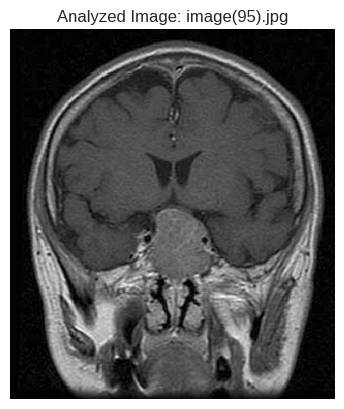

In [ ]:
import random
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

def get_random_test_image(base_path, classification_type='multiclass_classification'):
    test_dir = os.path.join(base_path, classification_type, 'test')
    image_paths = []
    for class_name in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(class_path, img_name))
    return random.choice(image_paths) if image_paths else None

def preprocess_image(image_path, target_size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def combined_diagnostic_pipeline(image_path, models, model_names):
    img_array = preprocess_image(image_path)

    results = []

    # EfficientNetB0 Binary
    model_name = model_names[0]
    model_bin_eff = models[0]
    is_tumor_prob_eff = model_bin_eff.predict(img_array, verbose=0)[0][0]
    if is_tumor_prob_eff >= 0.5:
        type_preds_eff_multi = models[1].predict(img_array, verbose=0)
        classes_multi = ['Glioma', 'Meningioma', 'Pituitary']
        detected_type = classes_multi[np.argmax(type_preds_eff_multi)]
        confidence = np.max(type_preds_eff_multi) * 100
        results.append({
            'model': f'{model_name} (Multiclass)',
            'prediction': f'Tumor detected. Suspected type: {detected_type}',
            'confidence': confidence
        })
    else:
        confidence = (1 - is_tumor_prob_eff) * 100
        results.append({
            'model': f'{model_name} (Binary)',
            'prediction': 'No tumor detected.',
            'confidence': confidence
        })

    # DenseNet121 Binary
    model_name = model_names[1]
    model_bin_dense = models[2]
    is_tumor_prob_dense = model_bin_dense.predict(img_array, verbose=0)[0][0]
    if is_tumor_prob_dense >= 0.5:
        type_preds_dense_multi = models[3].predict(img_array, verbose=0)
        classes_multi = ['Glioma', 'Meningioma', 'Pituitary'] # Assuming same classes
        detected_type = classes_multi[np.argmax(type_preds_dense_multi)]
        confidence = np.max(type_preds_dense_multi) * 100
        results.append({
            'model': f'{model_name} (Multiclass)',
            'prediction': f'Tumor detected. Suspected type: {detected_type}',
            'confidence': confidence
        })
    else:
        confidence = (1 - is_tumor_prob_dense) * 100
        results.append({
            'model': f'{model_name} (Binary)',
            'prediction': 'No tumor detected.',
            'confidence': confidence
        })

    # Determine the most confident prediction
    best_result = max(results, key=lambda x: x['confidence'])

    return best_result

# Load all trained models
binary_model_efficientnet = load_model('/content/model_bin.h5')
binary_model_efficientnet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

multiclass_model_efficientnet = load_model('/content/model_multi_fine_partial.h5')
multiclass_model_efficientnet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

binary_model_densenet = load_model('/content/model_bin_dense.h5')
binary_model_densenet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

# Use the already trained model_multi_dense directly as it was not saved to a file.
multiclass_model_densenet = model_multi_dense
multiclass_model_densenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

all_models = [
    binary_model_efficientnet,
    multiclass_model_efficientnet,
    binary_model_densenet,
    multiclass_model_densenet
]
model_labels = [
    'EfficientNetB0',
    'EfficientNetB0',
    'DenseNet121',
    'DenseNet121'
]

# Get a random test image
test_img_path = get_random_test_image(path2)

if test_img_path:
    print(f"Analyzing image: {test_img_path}")
    prediction = combined_diagnostic_pipeline(test_img_path, all_models, model_labels)
    print(f"\nFinal Prediction: {prediction['prediction']} (Confidence: {prediction['confidence']:.2f}%) by {prediction['model']}")

    # Display the image
    img = plt.imread(test_img_path)
    plt.imshow(img)
    plt.title(f"Analyzed Image: {os.path.basename(test_img_path)}")
    plt.axis('off')
    plt.show()
else:
    print("No test images found to proceed with diagnostic pipeline.")
